# Simulation studies: ARPLN-ICA

This notebook aims at reproducing the simulated studies of *Independent Component Discovery in Temporal count data*.

Through 3 scenarios, we evaluate the recoverability of the mixing function $\Gamma$ under finite sample regime. Comparison between ARPLN-ICA inferred with the AR variational proxy and MF is assessed, as well as standard ICA baselines (UwedgeICA / Picard).

# Effect of $\Gamma$ the mixing function

## Definition of the 3 scenarios

First, we generate the 3 scenarios where only $\Gamma$ varies. Seed 0 serves as a common seed for all scenarios to generate the model parameters; only $\Gamma$ changes.

In [1]:
import matplotlib.pyplot as plt
import torch
from plntime.models.plnica import PLNICA

seed = 0
seeds = [0, 1, 2, 3]

n = 150
T = 20
K = 12
d = 5
C = 1

pcounts = torch.zeros((n, T, K))

bases = {}

for i, seed in enumerate(seeds):
    base = PLNICA(
        counts=pcounts,
        latent_size=d,
        n_dynamics=C,
        offsets='zero',
        bias=False,
        seed=seed,
    )
    
    with torch.no_grad():
        
        if i == 0:
            base.Gamma.W.data = torch.randn_like(base.Gamma.W.data) * 0.6 + 4.5
        elif i == 1:
            # High coherence, mostly active and balanced prevalence
            base.Gamma.W.data = torch.abs(torch.randn_like(base.Gamma.W.data)) * 1.6 + torch.randn_like(base.Gamma.W.data) * 0.6
            base.offsets = base.offsets + 0.7
        elif i == 2:
            # Moderate coherence, mostly active but imbalance prevalence
            base.Gamma.W.data = torch.randn_like(base.Gamma.W.data) * 2.8 + (torch.randn_like(base.Gamma.W.data).abs().clamp_max(1.) * 0.9) + torch.randn_like(base.Gamma.W.data).abs() * 5.3
            base.offsets = base.offsets + 1.5 # old 1.2
        elif i == 3:
            # Zero-inflation in observations, low-excitation
            base.Gamma.W.data = torch.randn_like(base.Gamma.W.data) * 0.6 * torch.randn(1)
            
        if seed == 0:            
            # --- Dynamics mixture (irrelevant if C=1, but keep it sane)
            base.pi.data = torch.ones_like(base.pi.data) / base.pi.numel()
        
            # --- AR dynamics
            rho = 0.95
            base.B.data = torch.sigmoid(torch.ones_like(base.B.data) * rho + 3 * torch.randn_like(base.B.data))
            base.B.data[0] = -0.5 * base.B.data[0]
            base.B.data[3] = -0.5 * base.B.data[3]
            base.B.data[-1] = -2.0 * base.B.data[3]
        
            # --- Process noise
            base.psi.data = torch.ones_like(base.psi.data) * 0.08
        
            # --- Latent AR bias 
            base.b.data = torch.randn_like(base.b.data) * 0.5 + 0.5
            base.b.data[0] += 2.0
            base.b.data[1] += 0.4
        
            # --- Initial latent mean/cov
            base.bar_b.data = base.b.data + torch.randn_like(base.bar_b.data) * 0.05
            base.bar_psi.data = base.psi.data + torch.randn_like(base.bar_psi.data).abs() * 0.3
        
            base.offsets = 0. * torch.randn_like(base.offsets)
            base.M.data = torch.randn_like(base.M.data)*0
        else:
            base_ref = bases[0]
            base.pi.data = base_ref.pi.data.clone()
            base.B.data = base_ref.B.data.clone()
            base.psi.data = base_ref.psi.data.clone()
            base.b.data = base_ref.b.data.clone()
            base.bar_b.data = base_ref.bar_b.data.clone()
            base.bar_psi.data = base_ref.bar_psi.data.clone()
            base.M.data = base_ref.M.data.clone()

        bases[seed] = base

For each scenario, we visualise the statistics of interest:
- support of the log-intensities indicate excitation.
- Gram correlation coefficients indicate components entanglement.
- Conditioning indicates the difficulty to numerically estimate $\Gamma$ in standard numerical analysis.

Gram correlations (mean offdiag): 0.6473861105249811
Gram correlations (mean offdiag): 0.8709341367372953
Gram correlations (mean offdiag): 0.5131865799084707


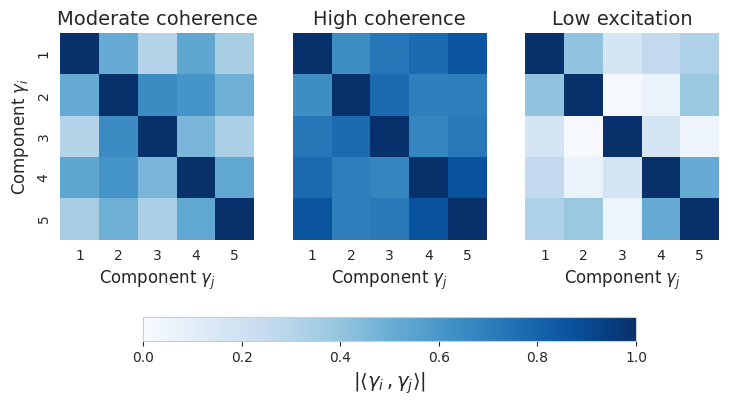

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('whitegrid')

fig, axes = plt.subplots(1, len(bases)-1, figsize=(8.5, 4), sharey=True)

titles = ["Moderate coherence", "High coherence", "Low excitation"]
mappable = None

for i, seed in enumerate([2, 1, 3]):
    base = bases[seed]
    with torch.no_grad():
        G = base.Gamma.normalize()
        Gram = (G.T @ G).abs().detach()
        mask = torch.tril(torch.ones_like(Gram, dtype=torch.bool), diagonal=-1)
        Gram_tril = Gram[mask]
        print("Gram correlations (mean offdiag):", Gram_tril.max().item())

    hm = sns.heatmap(
        Gram, ax=axes[i], vmin=0., vmax=1., cmap='Blues',
        cbar=False, linewidth=0., rasterized=True
    )
    mappable = hm.collections[0]

    xticks = axes[i].get_xticks()
    axes[i].set_xticks(xticks)
    axes[i].set_xticklabels([str(int(t) + 1) for t in xticks])

    yticks = axes[i].get_yticks()
    axes[i].set_yticks(yticks)
    axes[i].set_yticklabels([str(int(t) + 1) for t in yticks])

    axes[i].set_title(titles[i], fontsize=14)
    axes[i].set_xlabel(r"Component $\gamma_j$", fontsize=12)
    if i == 0:
        axes[i].set_ylabel(r"Component $\gamma_i$", fontsize=12)

cbar = fig.colorbar(mappable, ax=axes, orientation='horizontal', fraction=0.08, pad=0.25)
cbar.set_label(r"$|\langle \gamma_i\,, \gamma _j \rangle|$", fontsize=14)

plt.savefig('./figures/coherence_gram.pdf', bbox_inches='tight')


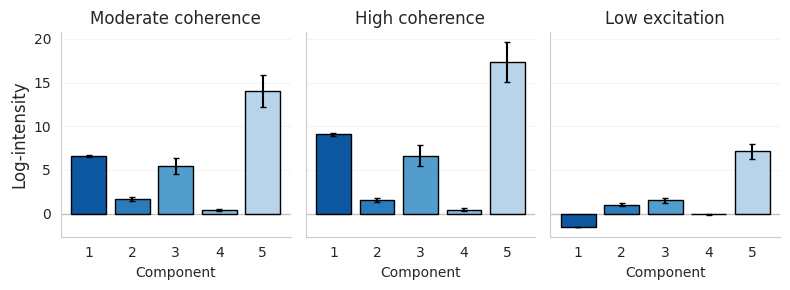

In [3]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
import seaborn as sns

sns.set_style("whitegrid")

fig, axes = plt.subplots(1, len(bases) - 1, figsize=(8, 3), sharey=True)

max_abs = 0.0

for i, seed in enumerate([2, 1, 3]):
    base = bases[seed]
    ax = axes[i]

    _, S_ref, _ = base.sample(500, seed=seed)

    G_ref = base.Gamma.normalize() 

    eta_samples = S_ref.unsqueeze(-1) * G_ref.t().unsqueeze(0).unsqueeze(0)

    logint_samples = eta_samples.sum(dim=-1).mean(dim=1).detach()

    logint_mean = logint_samples.mean(dim=0).cpu().numpy()
    logint_std = logint_samples.std(dim=0).cpu().numpy()

    d = logint_mean.shape[0]
    x = np.arange(d)

    cmap = plt.cm.Blues_r
    colors = cmap(np.linspace(0.15, 0.7, d))

    ax.bar(
        x, logint_mean,
        yerr=logint_std, capsize=2,
        color=colors,
        edgecolor="black", linewidth=1.0
    )

    ax.axhline(0.0, color="black", linewidth=1.0, alpha=0.2)

    ax.set_xlabel("Component")
    if i == 0:
        ax.set_ylabel("Log-intensity", fontsize=12)

    ax.set_xticks(x)
    ax.set_xticklabels([f"{c+1}" for c in range(d)])

    ax.grid(axis="x", alpha=0)
    ax.grid(axis="y", alpha=0.2)
    if seed == 1:
        ax.set_title('High coherence')
    elif seed == 2:
        ax.set_title('Moderate coherence')
    elif seed == 3:
        ax.set_title('Low excitation')


fig.tight_layout()
sns.despine(fig)
plt.savefig('./figures/log_intensity_scenarios.pdf')

## Samples generation and fit

We draw $n=150$ data points per scenario, then fit 10 ARPLN-ICA models with varying seeds on each of them to assess variability in recovery.

In [4]:
for i, (seed, base) in enumerate(bases.items()):
    X, S, U = base.sample(n, seed=seed)

In [5]:
# --------------------------------
# Fit PLNICA models with different random seeds
# --------------------------------

import numpy as np
import pickle
import os

n_seeds = 10
np.random.seed(42)
seeds_train = np.arange(0, 999)
np.random.shuffle(seeds_train)
seeds_train = seeds_train[:n_seeds]
print('Selected seeds:', seeds_train)

params = dict(
    amortized_size=4,
    n_layers_amortizer=2,
    n_output_layers_amortizer=2,
    shared_network_size=[16, 8],
    n_output_layers_shared=2
)

models = {}
losses = {}

for seed in seeds:
    if seed == 0:
        continue
    base = bases[seed]
    X = base.sample(n_samples=base.counts.shape[0], seed=seed)[0]
    print('Seed', seed)
    models[seed] = {}
    losses[seed] = {}
    print('AR')
    for s in seeds_train:
        path = f'./cache/GammaExp/AR-{seed}-train_{s}.pkl'
        if os.path.isfile(path):
            print('Loading from cache', path)
            with open(path, 'rb') as f:
                model = pickle.load(f)
            model.sample(10)
        else:
            model = PLNICA(
                counts=X,
                latent_size=base.d,
                n_dynamics=base.C,
                network_params=params,
                offsets=base.offsets[:X.shape[0]],
                seed=int(s),
                bias=False,
            )
        
            loss = model.fit(n_epochs=800, batch_size=X.shape[0])
            
            model.counts = model.counts[[0]]
            with open(path, 'wb') as f:
                pickle.dump(model, f)
            
        models[seed]['AR-' + str(s)] = model
    
    print('Mean field')
    for s in seeds_train:
        path = f'./cache/GammaExp/MF-{seed}-train_{s}.pkl'
        if os.path.isfile(path):
            print('Loading from cache', path)
            with open(path, 'rb') as f:
                model = pickle.load(f)
        else:
            model = PLNICA(
                counts=X,
                latent_size=base.d,
                n_dynamics=base.C,
                network_params=params,
                offsets=base.offsets[:X.shape[0]],
                mean_field=True,
                seed=int(s),
                bias=False
            )
        
            loss = model.fit(n_epochs=800, batch_size=X.shape[0])
            model.counts = model.counts[[0]]
            with open(path, 'wb') as f:
                pickle.dump(model, f)
            
        models[seed]['MF-' + str(s)] = model

Selected seeds: [453 793 209 309 740 578 895 545 436 678]
Seed 1
AR
Loading from cache ./cache/GammaExp/AR-1-train_453.pkl
Loading from cache ./cache/GammaExp/AR-1-train_793.pkl
Loading from cache ./cache/GammaExp/AR-1-train_209.pkl
Loading from cache ./cache/GammaExp/AR-1-train_309.pkl
Loading from cache ./cache/GammaExp/AR-1-train_740.pkl
Loading from cache ./cache/GammaExp/AR-1-train_578.pkl
Loading from cache ./cache/GammaExp/AR-1-train_895.pkl
Loading from cache ./cache/GammaExp/AR-1-train_545.pkl
Loading from cache ./cache/GammaExp/AR-1-train_436.pkl
Loading from cache ./cache/GammaExp/AR-1-train_678.pkl
Mean field
Loading from cache ./cache/GammaExp/MF-1-train_453.pkl
Loading from cache ./cache/GammaExp/MF-1-train_793.pkl
Loading from cache ./cache/GammaExp/MF-1-train_209.pkl
Loading from cache ./cache/GammaExp/MF-1-train_309.pkl
Loading from cache ./cache/GammaExp/MF-1-train_740.pkl
Loading from cache ./cache/GammaExp/MF-1-train_578.pkl
Loading from cache ./cache/GammaExp/MF-1-

## Evaluation of the recovery

**Evaluation of distribution recovery**: For each trained model, we sample $500$ samples (and similarly for the baseline) to assess the empirical sliced Wasserstein distance between the learned model and the baseline.

**Evaluation of mixing recovery**: For each trained model, we align the inferred mixing to the true one and assess cosine similarity. We also report recovery with baseline ICA algorithms (UwedgeICA / Picard).

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
seeds = [1, 2, 3]
# Posterior predictive check samples, for the sliced Wasserstein
X_models = {}
for seed in seeds:
    X_models[seed] = {}
    for key, model in models[seed].items():
        X_models[seed][key] = model.sample(500)[0]
    for s in seeds_train:
        X_models[seed][f'Baseline-{s}'] = bases[seed].sample(500, seed=int(s))[0]

In [7]:
import ot
import warnings
warnings.filterwarnings("ignore")

def method_from_name(name: str):
    if name == "Baseline" or name.startswith("Baseline"):
        return "Baseline"
    if name.startswith("AR-"):
        return "AR"
    if name.startswith("MF-"):
        return "MF"
    return None

def sliced_wasserstein(
    X_ref: torch.Tensor,
    X_s: torch.Tensor,
    n_projections: int = 1000,
    p: int = 2,
    seed: int = 0,
) -> float:
    """
    Compute Sliced Wasserstein distance between two datasets of time series.

    X_ref, X_s: torch tensors of shape (n, T, K)
    Flatten (T, K) -> d = T*K and compare empirical distributions in R^d.
    """
    Xr = torch.flatten(X_ref, start_dim=1).detach().to("cpu").double().numpy()
    Xq = torch.flatten(X_s, start_dim=1).detach().to("cpu").double().numpy()

    a = np.full(Xr.shape[0], 1.0 / Xr.shape[0], dtype=np.float64)
    b = np.full(Xq.shape[0], 1.0 / Xq.shape[0], dtype=np.float64)

    return float(
        ot.sliced_wasserstein_distance(
            Xr, Xq, a=a, b=b, n_projections=n_projections, p=p, seed=seed
        )
    )

def standardize_counts(X):
    X_log = torch.log(X + 1e-2)
    return (X_log - X_log.mean(dim=-1, keepdim=True))/X_log.std(dim=-1, keepdim=True)

In [8]:
# Computation of the sliced Wasserstein between the trained models and the baseline
rows = []
for seed in seeds:
    X_ref = bases[seed].sample(500, seed=seed)[0]
    for name, Xt in X_models[seed].items():
        method = method_from_name(name)
        if method is None:
            continue

        wass = sliced_wasserstein(standardize_counts(X_ref), standardize_counts(Xt))
    
        rows.append({
            "name": name,
            "method": method,
            f"Sliced Wasserstein-{seed}": wass,
        })

df_wass = pd.DataFrame(rows)

In [9]:
# Computation of baseline ICA algorithm

from baselines.ica_baseline import BatchedPicardICA, BatchedUwedgeICA
import random


scenario_label = {
    0: "Ill-conditioned",
    1: "High coherence",
    2: "Moderate coherence",
    3: "Low excitation",
}

rows = []
for seed in seeds:
    if seed == 0:
        continue
    Gamma_base = bases[seed].Gamma.normalize().detach()
    G_ref = Gamma_base

    for s in seeds_train:
        
        for competitor in ['Picard', 'UwedgeICA']:
            X = bases[seed].sample(n_samples=bases[seed].counts.shape[0], seed=int(s))[0]
            X_log = torch.log(X + 0.5)

            torch.manual_seed(42)
            np.random.seed(42)
            random.seed(42)
            
            if competitor == 'Picard':
                method = BatchedPicardICA(
                    d=bases[seed].d
                ).fit(X_log)
            elif competitor == 'UwedgeICA':
                method = BatchedUwedgeICA(
                    d=bases[seed].d,
                    window=10,
                    lags=np.arange(1, 9),
                    step=10,
                    instantcov=True,
                ).fit(X_log)
            G = torch.tensor(method.get_mixing())
            G = G / torch.linalg.norm(G, axis=0, keepdims=True)
            ref = PLNICA(
                        counts=X,
                        latent_size=bases[seed].d,
                        n_dynamics=bases[seed].C,
                        network_params=params,
                        offsets=bases[seed].offsets[:X.shape[0]],
                        seed=int(s),
                        bias=False,
                    )
            ref.Gamma.W.data = G
            G_ref = base.Gamma.normalize().detach()
            G_aligned, perm, sign, err = ref.identify(G_ref)
            col_cos = (G_aligned * G_ref).sum(dim=0).abs().cpu().numpy()
            for j, c in enumerate(col_cos, start=1):
                rows.append({
                    "Scenario": scenario_label[seed],
                    "Seed": seed,
                    "MethodLabel": competitor,
                    "Component": j,
                    "Cosine": float(c),
                })

df_competitors = pd.DataFrame(rows)
df_competitors

,Scenario,Seed,MethodLabel,Component,Cosine
0,High coherence,1,Picard,1,0.069403
1,High coherence,1,Picard,2,0.642390
2,High coherence,1,Picard,3,0.160894
3,High coherence,1,Picard,4,0.290026
4,High coherence,1,Picard,5,0.384099
...,...,...,...,...,...
295,Low excitation,3,UwedgeICA,1,0.374585
296,Low excitation,3,UwedgeICA,2,0.533539
297,Low excitation,3,UwedgeICA,3,0.538945
298,Low excitation,3,UwedgeICA,4,0.329077


Moderate coherence
  Auto-regressive: 0.75 ( 0.16 )
  Mean Field: 0.73 ( 0.15 )
  UwedgeICA: 0.46 ( 0.22 )
  Picard: 0.4 ( 0.17 )
High coherence
  Auto-regressive: 0.84 ( 0.12 )
  Mean Field: 0.87 ( 0.12 )
  UwedgeICA: 0.39 ( 0.14 )
  Picard: 0.33 ( 0.2 )
Low excitation
  Auto-regressive: 0.58 ( 0.27 )
  Mean Field: 0.56 ( 0.21 )
  UwedgeICA: 0.53 ( 0.2 )
  Picard: 0.6 ( 0.25 )


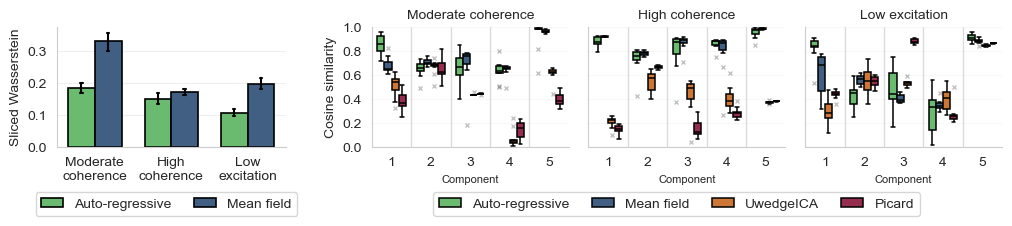

In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ----------------------------
# Select scenarios (seeds) and labels
# ----------------------------
seeds_keep = [2, 1, 3]  # e.g. [0, 2, 3] or [0,1,2,3]

scenario_order = [scenario_label[s] for s in seeds_keep]

scenario_order_nl = [s.replace(" ", "\n") for s in scenario_order]
scenario_label_nl = {k: v.replace(" ", "\n") for k, v in scenario_label.items()}
method_label = {"AR": "Auto-regressive", "MF": "Mean field"}

# ----------------------------
# Panel (a) data: Sliced Wasserstein
# ----------------------------
metrics_keep = [f"Sliced Wasserstein-{seed}" for seed in seeds_keep]

df_ppc = df_wass.melt(
    id_vars=["name", "method"],
    value_vars=metrics_keep,
    var_name="metric",
    value_name="value",
)
df_ppc["seed"] = df_ppc["metric"].str.split("-").str[-1].astype(int)
df_ppc = df_ppc[df_ppc["seed"].isin(seeds_keep)].copy()
df_ppc["Scenario"] = df_ppc["seed"].map(scenario_label)

df_ppc = df_ppc[df_ppc["method"].isin(["AR", "MF"])].copy()
df_ppc["MethodLabel"] = df_ppc["method"].map(method_label)
df_ppc["Scenario_nl"] = df_ppc["Scenario"].str.replace(" ", "\n")

# ----------------------------
# Panel (b) data: Cosines per component
# ----------------------------
rows = []
for seed in seeds_keep:
    G_ref = bases[seed].Gamma.normalize().detach()

    for name, model in models[seed].items():
        if name.startswith("AR-"):
            method = "AR"
        elif name.startswith("MF-"):
            method = "MF"
        else:
            continue

        Gamma_aligned, perm, sign, err = model.identify(G_ref)
        col_cos = (G_ref * Gamma_aligned).sum(dim=0).abs().cpu().numpy()

        for j, c in enumerate(col_cos, start=1):
            rows.append({
                "Scenario": scenario_label[seed],
                "Seed": seed,
                "MethodLabel": method_label[method],
                "Component": j,
                "Cosine": float(c),
            })

df_cos = pd.DataFrame(rows)
df_cos = pd.concat((df_cos, df_competitors))

#------------------------------

sns.set_style("whitegrid")

n_sc = len(seeds_keep)
fig = plt.figure(figsize=(12.2, 2.))

gs = fig.add_gridspec(
    nrows=1, ncols=2,
    width_ratios=[1., 2.75],
    wspace=0.2
)

ax_ppc = fig.add_subplot(gs[0, 0])

gs_cos = gs[0, 1].subgridspec(
    nrows=1, ncols=n_sc,
    wspace=0.10
)

axes_cos = []
axes_cos.append(fig.add_subplot(gs_cos[0, 0]))
for i in range(1, n_sc):
    axes_cos.append(fig.add_subplot(gs_cos[0, i], sharey=axes_cos[0]))

cmap = plt.cm.viridis_r
import cmasher
method_palette = {
    "Auto-regressive": cmap(0.25),
    "Mean field":      cmap(0.70),
    "UwedgeICA":       cmasher.pride(0.65),  
    "Picard":          cmasher.pride(0.8), 
}

# ----------------------------
# (a) Sliced Wasserstein barplot
# ----------------------------
hue_order_ppc = ["Auto-regressive", "Mean field"]

ax_ppc.grid(False)
ax_ppc.yaxis.grid(True, alpha=0.3)

sns.barplot(
    data=df_ppc,
    x="Scenario_nl", y="value",
    order=scenario_order_nl,
    hue="MethodLabel",
    hue_order=hue_order_ppc,
    palette=method_palette,
    errorbar=("ci", 95),
    width=0.7,
    capsize=0.06, err_kws={'linewidth': 1.5, 'color': 'k'},
    edgecolor="black", linewidth=1.2,
    ax=ax_ppc
)

ax_ppc.set_xlabel("")
ax_ppc.set_ylabel("Sliced Wasserstein", fontsize=10)
ax_ppc.set_yticks([0, 0.1, 0.2, 0.3])
for lab in ax_ppc.get_xticklabels():
    lab.set_fontsize(10)

handles_ppc, labels_ppc = ax_ppc.get_legend_handles_labels()
leg = ax_ppc.get_legend()
if leg is not None:
    leg.remove()

# ----------------------------
# (b) Cosine similarity boxplots per scenario
# ----------------------------
hue_order_cos = ["Auto-regressive", "Mean field", "UwedgeICA", "Picard"]

for idx, (ax, seed) in enumerate(zip(axes_cos, seeds_keep)):
    scen = scenario_label[seed]
    scen_nl = scenario_label[seed]
    sub = df_cos[df_cos["Scenario"] == scen].copy()

    sns.boxplot(
        data=sub,
        x="Component",
        y="Cosine",
        hue="MethodLabel",
        hue_order=hue_order_cos,
        palette=method_palette,
        width=0.72,
        flierprops=dict(marker='x', markersize=3, alpha=0.3),
        boxprops=dict(edgecolor="black", linewidth=1.1),
        whiskerprops=dict(color="black", linewidth=1.1),
        capprops=dict(color="black", linewidth=1.1),
        medianprops=dict(color="black", linewidth=1.1),
        ax=ax
    )

    sep_color = "0.5"  
    n_comp = sub["Component"].nunique()
    for x in range(n_comp - 1):
        ax.axvline(x + 0.5, linestyle="-", color=sep_color, alpha=0.28,
                   linewidth=1.0, zorder=0)

    ax.grid(False)
    ax.yaxis.grid(True, alpha=0.15)
    ax.xaxis.grid(False)

    print(scen)
    print('  Auto-regressive:', sub[sub['MethodLabel'] == 'Auto-regressive']['Cosine'].mean().round(2),
          '(', sub[sub['MethodLabel'] == 'Auto-regressive']['Cosine'].std().round(2), ')')
    print('  Mean Field:', sub[sub['MethodLabel'] == 'Mean field']['Cosine'].mean().round(2),
          '(', sub[sub['MethodLabel'] == 'Mean field']['Cosine'].std().round(2), ')')
    print('  UwedgeICA:', sub[sub['MethodLabel'] == 'UwedgeICA']['Cosine'].mean().round(2),
          '(', sub[sub['MethodLabel'] == 'UwedgeICA']['Cosine'].std().round(2), ')')
    print('  Picard:', sub[sub['MethodLabel'] == 'Picard']['Cosine'].mean().round(2),
          '(', sub[sub['MethodLabel'] == 'Picard']['Cosine'].std().round(2), ')')

    ax.set_title(scen_nl, fontsize=10, pad=6)

    ax.set_xlabel("Component", fontsize=8)
    ax.set_ylabel("Cosine similarity" if idx == 0 else "", fontsize=10)

    if idx != 0:
        ax.tick_params(axis="y", labelleft=False)
    if idx == 0:
        ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_ylim(ymin=0, ymax=1.)

    if idx == 0:
        handles_cos, labels_cos = ax.get_legend_handles_labels()

    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

# ----------------------------
# Separate legends below each panel
# ----------------------------
y_legend = -0.1
leg_ppc = fig.legend(
    handles_ppc, labels_ppc,
    loc="lower center",
    ncol=2,
    bbox_to_anchor=(0.215, y_legend), 
    frameon=True,
    fontsize=10,
    handlelength=1.6,
    columnspacing=1.6,
)

leg_cos = fig.legend(
    handles_cos, labels_cos,
    loc="lower center",
    ncol=4,
    bbox_to_anchor=(0.633, y_legend), 
    frameon=True,
    fontsize=10,
    handlelength=1.6,
    columnspacing=1.6,
)
fig.subplots_adjust(bottom=0.28)

sns.despine(fig)
plt.savefig("./figures/identifiability/identifiability_by_scenario.pdf", bbox_inches="tight")

# Varying the effective training size

## Effect of $n$ on recovery

In this additional study, we vary the number of training samples in the *moderate coherence* scenario to assess the impact of $n$ on the recovery and wall-clock time.

In [11]:
# Selection of the scenario, seed = 2 is the moderate coherence

seed = 2

n = 200
T = 20
K = 12
d = 5
C = 1

pcounts = torch.zeros((n, T, K))

base = bases[seed]

In [12]:
# Sample
X, S, U = base.sample(base.offsets.shape[0], seed=seed)

In [13]:
# --------------------------------
# Fit PLNICA models with different random seeds
# --------------------------------

import numpy as np
import pickle
import os

n_seeds = 10
np.random.seed(42)
seeds = np.arange(0, 999)
np.random.shuffle(seeds)
seeds = seeds[:n_seeds]
print('Selected seeds:', seeds)

n_list = [5, 30, 50, 80, 100, 150]

params = dict(
    amortized_size=4,
    n_layers_amortizer=2,
    n_output_layers_amortizer=2,
    shared_network_size=[16, 8],
    n_output_layers_shared=2
)

models = {}
losses = {}

for n_train in n_list:
    print('Size', n_train)
    X_train = X[:n_train]
    models[n_train] = {}
    losses[n_train] = {}
    print('AR')
    for s in seeds:
        path = f'./cache/n_effect_scenario{seed}/AR-n{n_train}-train_{s}.pkl'
        if os.path.isfile(path):
            print('Loading from cache', path)
            with open(path, 'rb') as f:
                model = pickle.load(f)
            model.sample(10)
        else:
            model = PLNICA(
                counts=X_train,
                latent_size=base.d,
                n_dynamics=base.C,
                network_params=params,
                offsets=base.offsets[:X_train.shape[0]],
                seed=int(s),
                bias=False,
            )
        
            loss = model.fit(n_epochs=800, batch_size=X.shape[0])
            
            model.counts = model.counts[[0]]
            with open(path, 'wb') as f:
                pickle.dump(model, f)
            
        models[n_train]['AR-' + str(s)] = model
    
    print('Mean field')
    for s in seeds:
        path = f'./cache/n_effect_scenario{seed}/MF-n{n_train}-train_{s}.pkl'
        if os.path.isfile(path):
            print('Loading from cache', path)
            with open(path, 'rb') as f:
                model = pickle.load(f)
        else:
            model = PLNICA(
                counts=X_train,
                latent_size=base.d,
                n_dynamics=base.C,
                network_params=params,
                offsets=base.offsets[:X_train.shape[0]],
                mean_field=True,
                seed=int(s),
                bias=False
            )
        
            loss = model.fit(n_epochs=800, batch_size=X.shape[0])
            model.counts = model.counts[[0]]
            with open(path, 'wb') as f:
                pickle.dump(model, f)
            
        models[n_train]['MF-' + str(s)] = model

Selected seeds: [453 793 209 309 740 578 895 545 436 678]
Size 5
AR
Loading from cache ./cache/n_effect_scenario2/AR-n5-train_453.pkl
Loading from cache ./cache/n_effect_scenario2/AR-n5-train_793.pkl
Loading from cache ./cache/n_effect_scenario2/AR-n5-train_209.pkl
Loading from cache ./cache/n_effect_scenario2/AR-n5-train_309.pkl
Loading from cache ./cache/n_effect_scenario2/AR-n5-train_740.pkl
Loading from cache ./cache/n_effect_scenario2/AR-n5-train_578.pkl
Loading from cache ./cache/n_effect_scenario2/AR-n5-train_895.pkl
Loading from cache ./cache/n_effect_scenario2/AR-n5-train_545.pkl
Loading from cache ./cache/n_effect_scenario2/AR-n5-train_436.pkl
Loading from cache ./cache/n_effect_scenario2/AR-n5-train_678.pkl
Mean field
Loading from cache ./cache/n_effect_scenario2/MF-n5-train_453.pkl
Loading from cache ./cache/n_effect_scenario2/MF-n5-train_793.pkl
Loading from cache ./cache/n_effect_scenario2/MF-n5-train_209.pkl
Loading from cache ./cache/n_effect_scenario2/MF-n5-train_309.p

In [14]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Trained models samples
X_models = {}
for n_train in n_list:
    X_models[n_train] = {}
    for key, model in models[n_train].items():
        X_models[n_train][key] = model.sample(500)[0]
    for s in seeds:
        X_models[n_train][f'Baseline-{s}'] = base.sample(500, seed=int(s))[0]

In [15]:
# -----------------------
# Sliced wasserstein reference stats
# -----------------------
X_ref = base.sample(1000, seed=seed)[0]

eps = 1e-8
rows = []

for n_train in n_list:
    for name, Xt in X_models[n_train].items():
        method = method_from_name(name)
        if method is None:
            continue

        wass = sliced_wasserstein(standardize_counts(X_ref), standardize_counts(Xt))
    
        rows.append({
            "name": name,
            "method": method,
            f"Sliced Wasserstein-{n_train}": wass,
        })

df_wass = pd.DataFrame(rows)

Cosine similarity summary:
-----------------------
Mean cosine AR: 0.7614 (0.1527)
AR-5
AR-30
AR-50
AR-80
AR-100
AR-150


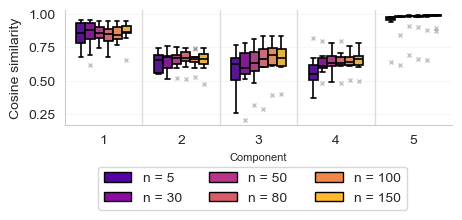

In [16]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.offsetbox import AnchoredOffsetbox, TextArea, HPacker, DrawingArea

fig, ax = plt.subplots(figsize=(5., 1.5))

cmap = plt.cm.plasma
hue_order = ['n = ' + x.split('-')[-1] + '' for x in list(df_wass.columns[2:])]
metric_palette = {
    lab: cmap(x) for lab, x in zip(hue_order, np.linspace(0.15, 0.85, len(hue_order)))
}

Gamma_base = base.Gamma.normalize().detach()
G_ref = Gamma_base

rows = []
gram_error = {}

for n_train in n_list:
    for name, model in models[n_train].items():
        if name.startswith("AR-"):
            group = f"AR-{n_train}"
        elif name.startswith("MF-"):
            group = f"MF-{n_train}"
            continue
        else:
            continue
        if group not in gram_error:
            gram_error[group] = []
        Gamma_aligned, perm, sign, err = model.identify(G_ref)
    
        # per-column |cos|
        col_cos = (G_ref * Gamma_aligned).sum(dim=0).abs().cpu().numpy()  # (d,)
        d = len(col_cos)
        for j in range(d):
            rows.append({"Model": group, "Component": j + 1, "Cosine": col_cos[j]})
    
        # Gram error
        Delta = (G_ref.T @ G_ref) - (Gamma_aligned.T @ Gamma_aligned)
        rel_err = (torch.linalg.norm(Delta) / torch.linalg.norm(G_ref.T @ G_ref)).item()
        gram_error[group].append(rel_err)

df_long = pd.DataFrame(rows)

df_long["n_label"] = df_long["Model"].str.replace("AR-", "n = ", regex=False)

for n_train in n_list:
    mu_ge_ar = float(np.mean(df_long[df_long['Model'] == f"AR-{n_train}"]['Cosine']))
    sd_ge_ar = float(np.std(df_long[df_long['Model'] == f"AR-{n_train}"]['Cosine']))
    mu_ge_mf = float(np.mean(df_long[df_long['Model'] == f"MF-{n_train}"]['Cosine']))
    sd_ge_mf = float(np.std(df_long[df_long['Model'] == f"MF-{n_train}"]['Cosine']))
print('Cosine similarity summary:')
print("-----------------------")
print(f"Mean cosine AR: {mu_ge_ar:.4f} ({sd_ge_ar:.4f})")
for model in df_long.Model.unique():
    print(model)
    for c in df_long.Component.unique():
        values = df_long[(df_long['Component'] == c) & (df_long['Model'] == model)]['Cosine']
        ci_lo = np.quantile(values, 0.05)
        ci_hi = np.quantile(values, 0.95)
        m = values.mean()

sep_color = "0.5"  # grey (0=black, 1=white)
for x in range(d - 1):
    ax.axvline(x + 0.5, linestyle="-", color=sep_color, alpha=0.28,
                   linewidth=1.0, zorder=0)

ax.grid(False)
ax.yaxis.grid(True, alpha=0.15)
ax.xaxis.grid(False)

ax.xaxis.grid(False)
sns.boxplot(
    data=df_long,
    x="Component",
    y="Cosine",
    hue="n_label",
    palette=metric_palette,
    ax=ax,
    flierprops=dict(marker='x', markersize=3, alpha=0.3),
    width=0.7,
    boxprops=dict(edgecolor="black", linewidth=1.2),
    whiskerprops=dict(color="black", linewidth=1.2),
    capprops=dict(color="black", linewidth=1.2),
    medianprops=dict(color="black", linewidth=1.2),
)

ax.set_ylabel("Cosine similarity", fontsize=10)
ax.set_xlabel("Component", fontsize=8)

if ax.get_legend() is not None:
    ax.get_legend().remove()

legend_handles = [
    mpatches.Patch(facecolor=metric_palette[lab], edgecolor="black", label=lab)
    for lab in hue_order
]
fig.legend(
    handles=legend_handles,
    labels=hue_order,
    title="",
    frameon=True,
    ncol=3,
    loc="upper center",
    fontsize=10,
    bbox_to_anchor=(0.5, -0.12),
)

sns.despine(fig)
plt.savefig(f'./figures/identifiability/grouped_identifiability_benchmark_varying_n_simple_case_{seed}.pdf', bbox_inches='tight')

## Timings with $n$ and $T$

We vary $n$ and $T$ in the *moderate scenario* to assess wall-clock time effects. For a fixed $n$ and $T$, we fit an ARPLN-ICA models as below and report the total time divided by the number of epochs required to reach the said time in the dictionary `timings` below.

In [18]:
n_samples = 5
T = 10

base.T = T
model = PLNICA(
    counts=base.sample(n_samples)[0],
    latent_size=base.d,
    n_dynamics=base.C,
    network_params=params,
    offsets=base.offsets.repeat(20, 2)[:n_samples, :T],
    seed=42,
    bias=False,
    device='cuda'
)
        
loss = model.fit(n_epochs=800, batch_size=X.shape[0])

 77%|███████▋  | 614/800 [00:45<00:13, 13.48it/s, Loss=0.884, Status=Converged]                                        


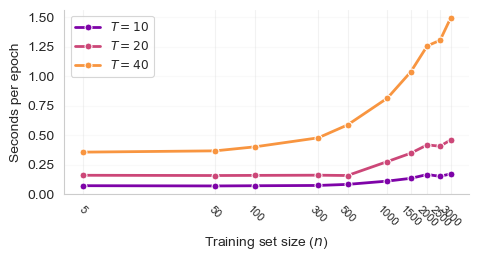

In [19]:
import matplotlib.ticker as mticker
import matplotlib as mpl

# Timings reported in seconds / number of epochs over varying parameters in the above cell.
timings = {
    10:{
        5: 36 / 496,
        50: 32 / 454,
        100: 33 / 457,
        300: 37 / 496,
        500: 42 / 502,
        1000: 57 / 511,
        1500: 68 / 504,
        2000: 84 / 502,
        2500: 76 / 500,
        3000: 87 / 504,
    },
    20:{
        5: 121 / 752,
        50: 121 / 762,
        100: 122 / 763,
        300: 121 / 749,
        500: 119 / 749,
        1000: 210 / 758,
        1500: 265 / 762,
        2000: 319 / 762,
        2500: 311 / 764,
        3000: 352 / 765
    },
    40:{
        5:  282 / 790,
        50:  284 / 772,
        100:  316 / 786,
        300:  374 / 782,
        500:  463 / 788,
        1000:  643 / 789,
        1500:  815 / 786,
        2000:  986 / 784,
        2500:  1027 / 787,
        3000:  1167 / 782,
    },
}

fig, ax = plt.subplots(figsize=(4.8, 2.7))
for i, T_ref in enumerate(timings): 
    x = np.array(list(timings[T_ref].keys()))
    y = np.array(list(timings[T_ref].values()))

    df = pd.DataFrame({"N": x, "sec_per_epoch": y}).sort_values("N")
    
    sns.set_theme(style="whitegrid", context="paper")
    
    sns.lineplot(
        data=df, x="N", y="sec_per_epoch",
        marker="o", markersize=5, linewidth=2,
        ax=ax, label='$T =' + str(int(T_ref)) + '$',
        color=mpl.colormaps.get_cmap('plasma')((i+1)/(len(timings)+1))
    )
    
    ax.set_xscale("log")
    ax.set_xlabel("Training set size ($n$)")
    ax.set_ylabel("Seconds per epoch")
    
    major_ticks = df["N"].to_list()
    ax.set_xticks(major_ticks)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, pos: f"{int(v)}"))
    
    ax.xaxis.set_minor_locator(mticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1))
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())  # keep minor ticks unlabeled (clean look)
    ax.tick_params(axis="x", which="major", labelsize=8, rotation=-45)

ax.grid(axis='x', alpha=0.25)
ax.grid(axis='y', alpha=0.1)
fig.tight_layout()
sns.despine(fig)
plt.savefig('./figures/timings_moderate_coherence_case.pdf', bbox_inches='tight')